# Лабораторная работа №2.4_GAN
##
### Дедлайн для загрузки 05.06.2026


# Задание
1. Реализайте архитектуру GAN на датасете FashionMNIST, где генератор будет написан на архитектуре сверточной сети
2. Реализуйте архитектуру сверточной нейронной сети, которая будет обучена на датасете FashionMNIST, для классификации ваших сгенерированных изображений
3. Прокомментировать цикл обучения (дать комментарии кода процесса обучения)

# Оценка будет снижена, если
1) Архитектура генератора написана без использование сверточных слоев -
2) Обучение модели написано не для GPU -
3) Нет никаких комментариев в работе -

# Решение

В работе реализована DCGAN-подобная архитектура для FashionMNIST. Генератор использует сверточные транспонированные слои (`ConvTranspose2d`), дискриминатор использует обычные сверточные слои, а затем отдельно обучается CNN-классификатор для распознавания сгенерированных изображений.

Ноутбук не требует `torchvision`: FashionMNIST скачивается напрямую из официального репозитория Zalando и читается из IDX-файлов.

In [ ]:
from pathlib import Path
import gzip
import random
import struct
import time
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path.cwd() / "data" / "fashion_mnist"

LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS_GAN = 15
EPOCHS_CLASSIFIER = 15
LR_GAN = 2e-4
LR_CLASSIFIER = 1e-3


TRAIN_LIMIT = 8192
TEST_LIMIT = 2048

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

print("Device:", DEVICE)

Device: cpu


In [2]:
FASHION_MNIST_URLS = {
    "train_images": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz",
    "train_labels": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-labels-idx1-ubyte.gz",
    "test_images": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz",
}


def download_fashion_mnist(data_dir=DATA_DIR):
    data_dir.mkdir(parents=True, exist_ok=True)
    for name, url in FASHION_MNIST_URLS.items():
        target = data_dir / f"{name}.gz"
        if target.exists():
            continue
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, target)
    print("FashionMNIST files are ready:", data_dir)


def read_idx_images(path):
    with gzip.open(path, "rb") as f:
        magic, count, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image file magic number: {magic}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(count, rows, cols)


def read_idx_labels(path):
    with gzip.open(path, "rb") as f:
        magic, count = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label file magic number: {magic}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


class FashionMNISTLocal(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels.astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.float32) / 255.0
        # Для GAN используем диапазон [-1, 1], потому что генератор заканчивается Tanh.
        image = image * 2.0 - 1.0
        image = torch.from_numpy(image).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


download_fashion_mnist()
train_images = read_idx_images(DATA_DIR / "train_images.gz")
train_labels = read_idx_labels(DATA_DIR / "train_labels.gz")
test_images = read_idx_images(DATA_DIR / "test_images.gz")
test_labels = read_idx_labels(DATA_DIR / "test_labels.gz")

train_dataset_full = FashionMNISTLocal(train_images, train_labels)
test_dataset_full = FashionMNISTLocal(test_images, test_labels)

train_dataset = Subset(train_dataset_full, range(min(TRAIN_LIMIT, len(train_dataset_full))))
test_dataset = Subset(test_dataset_full, range(min(TEST_LIMIT, len(test_dataset_full))))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

FashionMNIST files are ready: c:\Users\Ivan\Desktop\Учеба финка\петрунина\2.4\data\fashion_mnist
Train samples: 8192
Test samples: 2048


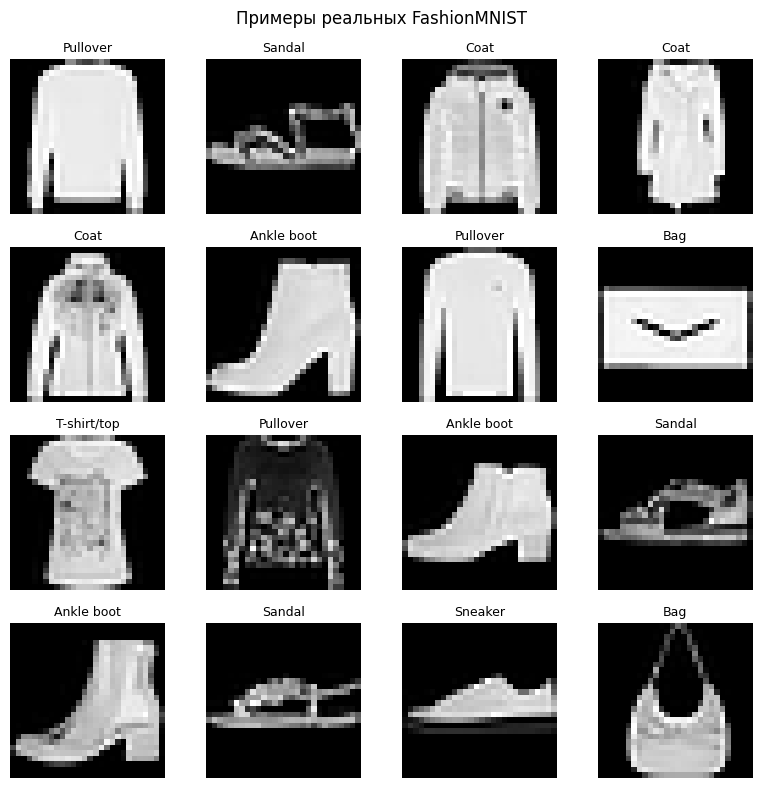

In [5]:
def denormalize_images(images):
    return (images.detach().cpu() + 1.0) / 2.0


def show_image_grid(images, title, labels=None, rows=4, cols=4):
    images = denormalize_images(images[: rows * cols])
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i].squeeze(0), cmap="gray")
        if labels is not None:
            ax.set_title(str(labels[i]), fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()

real_images, real_labels = next(iter(train_loader))
real_label_names = [CLASS_NAMES[label] for label in real_labels[:16].tolist()]
show_image_grid(real_images, "Примеры реальных FashionMNIST", real_label_names)

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(inplace=True),
        )
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7x7 -> 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),    # 14x14 -> 28x28
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.project(z).view(z.size(0), 128, 7, 7)
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),   # 28x28 -> 14x14
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 14x14 -> 7x7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
        )

    def forward(self, x):
        return self.net(x)


class FashionCNNClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)
classifier = FashionCNNClassifier().to(DEVICE)

print("Generator parameters:", count_parameters(G))
print("Discriminator parameters:", count_parameters(D))
print("Classifier parameters:", count_parameters(classifier))

Generator parameters: 778305
Discriminator parameters: 138817
Classifier parameters: 421642


Epoch 01/15 | G loss=2.6942 | D loss=0.2835 | time=4.2s
Epoch 02/15 | G loss=2.7841 | D loss=0.2711 | time=2.3s
Epoch 03/15 | G loss=2.7494 | D loss=0.3029 | time=2.3s
Epoch 04/15 | G loss=2.6897 | D loss=0.3223 | time=2.3s
Epoch 05/15 | G loss=2.6469 | D loss=0.3473 | time=2.2s
Epoch 06/15 | G loss=2.5620 | D loss=0.3621 | time=2.2s
Epoch 07/15 | G loss=2.4896 | D loss=0.3726 | time=2.2s
Epoch 08/15 | G loss=2.4292 | D loss=0.4345 | time=2.2s
Epoch 09/15 | G loss=2.3891 | D loss=0.4552 | time=2.2s
Epoch 10/15 | G loss=2.2974 | D loss=0.4096 | time=2.2s
Epoch 11/15 | G loss=2.2679 | D loss=0.4751 | time=2.2s
Epoch 12/15 | G loss=2.2417 | D loss=0.4454 | time=2.2s
Epoch 13/15 | G loss=2.2111 | D loss=0.4733 | time=2.2s
Epoch 14/15 | G loss=2.2388 | D loss=0.4546 | time=2.2s
Epoch 15/15 | G loss=2.2185 | D loss=0.4886 | time=2.2s


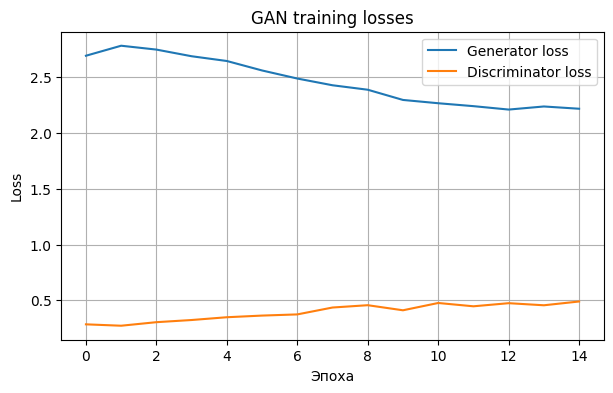

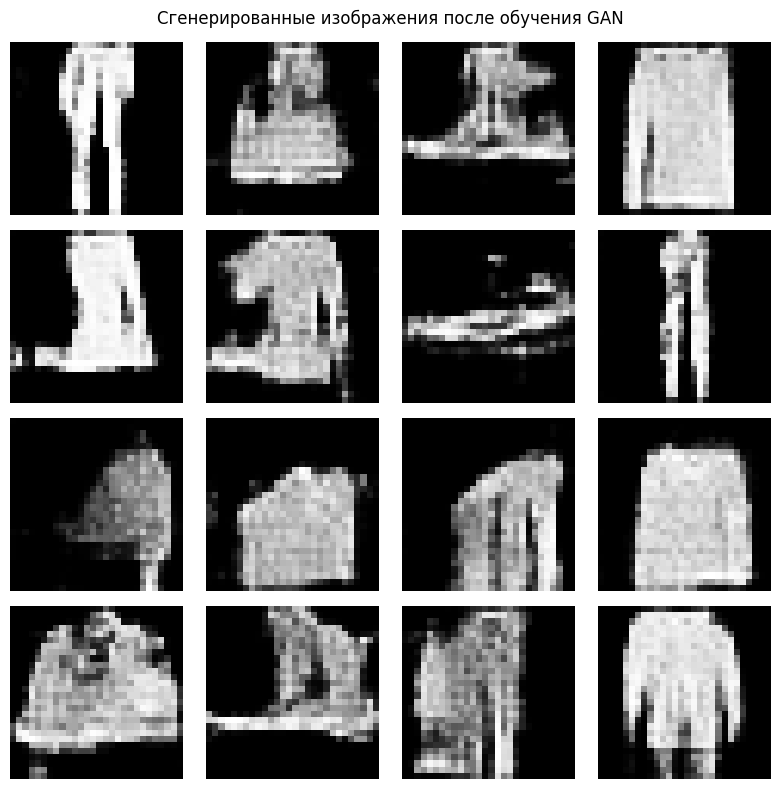

In [6]:
def train_gan(generator, discriminator, loader, epochs=EPOCHS_GAN):
    criterion = nn.BCEWithLogitsLoss()
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LR_GAN, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LR_GAN, betas=(0.5, 0.999))
    history = {"g_loss": [], "d_loss": []}

    fixed_noise = torch.randn(16, LATENT_DIM, device=DEVICE)

    for epoch in range(1, epochs + 1):
        generator.train()
        discriminator.train()
        g_losses, d_losses = [], []
        started = time.time()

        for real_images, _ in loader:
            real_images = real_images.to(DEVICE)
            batch_size = real_images.size(0)
            real_targets = torch.ones(batch_size, 1, device=DEVICE)
            fake_targets = torch.zeros(batch_size, 1, device=DEVICE)

            # 1. Обучаем дискриминатор: он должен отличать реальные изображения от сгенерированных.
            optimizer_d.zero_grad()
            real_logits = discriminator(real_images)
            real_loss = criterion(real_logits, real_targets)

            noise = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
            fake_images = generator(noise)
            # detach() запрещает обновлять генератор во время шага дискриминатора.
            fake_logits = discriminator(fake_images.detach())
            fake_loss = criterion(fake_logits, fake_targets)

            d_loss = real_loss + fake_loss
            d_loss.backward()
            optimizer_d.step()

            # 2. Обучаем генератор: он пытается сделать такие изображения,
            # которые дискриминатор примет за реальные.
            optimizer_g.zero_grad()
            generated_logits = discriminator(fake_images)
            g_loss = criterion(generated_logits, real_targets)
            g_loss.backward()
            optimizer_g.step()

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        history["g_loss"].append(float(np.mean(g_losses)))
        history["d_loss"].append(float(np.mean(d_losses)))
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"G loss={history['g_loss'][-1]:.4f} | "
            f"D loss={history['d_loss'][-1]:.4f} | "
            f"time={time.time() - started:.1f}s"
        )

    generator.eval()
    with torch.no_grad():
        samples = generator(fixed_noise).cpu()
    return history, samples

gan_history, generated_samples = train_gan(G, D, train_loader)

plt.figure(figsize=(7, 4))
plt.plot(gan_history["g_loss"], label="Generator loss")
plt.plot(gan_history["d_loss"], label="Discriminator loss")
plt.title("GAN training losses")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

show_image_grid(generated_samples, "Сгенерированные изображения после обучения GAN")

Epoch 01/15 | train_loss=1.0811 | test_acc=0.7695 | time=0.9s
Epoch 02/15 | train_loss=0.6211 | test_acc=0.7944 | time=0.9s
Epoch 03/15 | train_loss=0.5275 | test_acc=0.8257 | time=0.8s
Epoch 04/15 | train_loss=0.4693 | test_acc=0.8511 | time=0.8s
Epoch 05/15 | train_loss=0.4362 | test_acc=0.8530 | time=0.8s
Epoch 06/15 | train_loss=0.3977 | test_acc=0.8647 | time=0.8s
Epoch 07/15 | train_loss=0.3856 | test_acc=0.8726 | time=0.8s
Epoch 08/15 | train_loss=0.3513 | test_acc=0.8740 | time=0.8s
Epoch 09/15 | train_loss=0.3400 | test_acc=0.8760 | time=0.9s
Epoch 10/15 | train_loss=0.3263 | test_acc=0.8677 | time=0.8s
Epoch 11/15 | train_loss=0.3033 | test_acc=0.8828 | time=0.8s
Epoch 12/15 | train_loss=0.2875 | test_acc=0.8857 | time=0.8s
Epoch 13/15 | train_loss=0.2789 | test_acc=0.8828 | time=0.8s
Epoch 14/15 | train_loss=0.2629 | test_acc=0.8843 | time=0.8s
Epoch 15/15 | train_loss=0.2575 | test_acc=0.8862 | time=0.8s


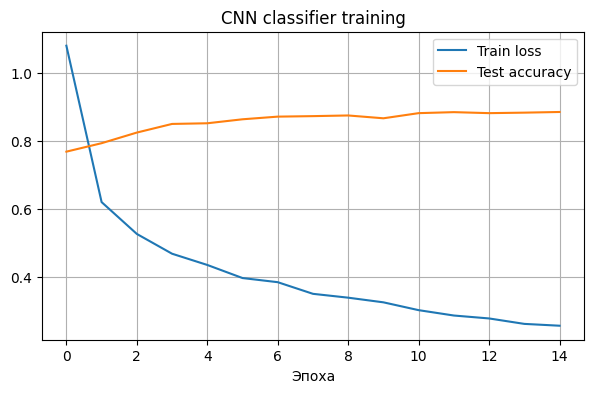

In [7]:
def images_for_classifier(images):
    # Классификатору удобнее диапазон [0, 1], поэтому переводим из GAN-нормализации [-1, 1].
    return (images + 1.0) / 2.0


def train_classifier(model, train_loader, test_loader, epochs=EPOCHS_CLASSIFIER):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR_CLASSIFIER)
    history = {"train_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        started = time.time()

        for images, labels in train_loader:
            images = images_for_classifier(images.to(DEVICE))
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        test_acc = evaluate_classifier(model, test_loader)
        history["train_loss"].append(float(np.mean(train_losses)))
        history["test_acc"].append(test_acc)
        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={history['train_loss'][-1]:.4f} | "
            f"test_acc={test_acc:.4f} | "
            f"time={time.time() - started:.1f}s"
        )
    return history


@torch.no_grad()
def evaluate_classifier(model, loader):
    model.eval()
    correct, total = 0, 0
    for images, labels in loader:
        images = images_for_classifier(images.to(DEVICE))
        labels = labels.to(DEVICE)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.numel()
    return correct / total

classifier_history = train_classifier(classifier, train_loader, test_loader)

plt.figure(figsize=(7, 4))
plt.plot(classifier_history["train_loss"], label="Train loss")
plt.plot(classifier_history["test_acc"], label="Test accuracy")
plt.title("CNN classifier training")
plt.xlabel("Эпоха")
plt.legend()
plt.grid(True)
plt.show()

Предсказанные классы для сгенерированных изображений:
01. Sandal       | confidence=0.976
02. Shirt        | confidence=0.813
03. Ankle boot   | confidence=0.805
04. Trouser      | confidence=1.000
05. Trouser      | confidence=1.000
06. Shirt        | confidence=0.752
07. Dress        | confidence=0.427
08. Pullover     | confidence=0.842
09. Dress        | confidence=0.549
10. Trouser      | confidence=0.544
11. Shirt        | confidence=0.603
12. Bag          | confidence=0.413
13. Coat         | confidence=0.692
14. Shirt        | confidence=0.460
15. Ankle boot   | confidence=0.544
16. Shirt        | confidence=0.565


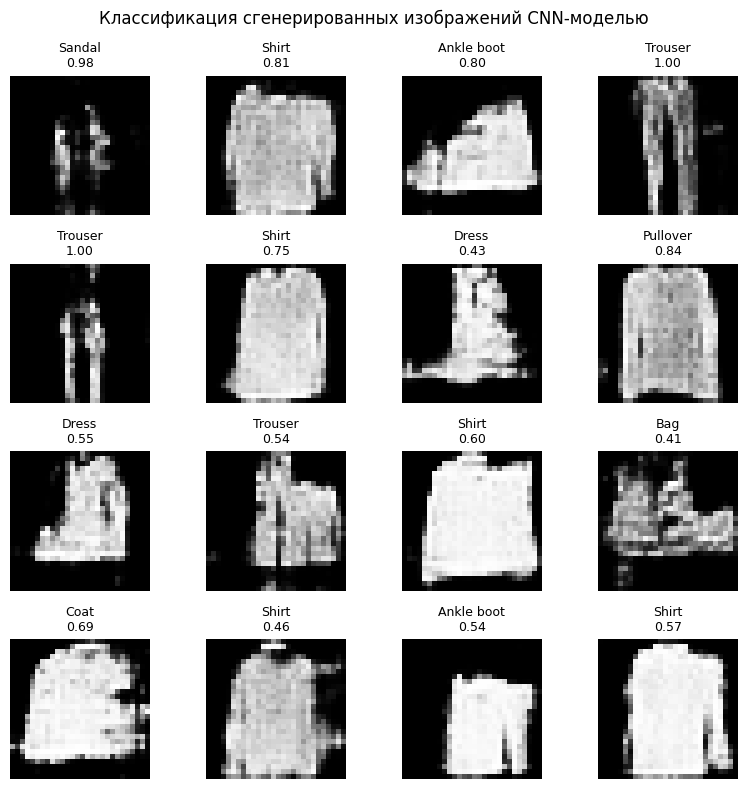

In [8]:
@torch.no_grad()
def generate_and_classify(generator, classifier, count=16):
    generator.eval()
    classifier.eval()
    noise = torch.randn(count, LATENT_DIM, device=DEVICE)
    generated = generator(noise)
    logits = classifier(images_for_classifier(generated))
    probabilities = torch.softmax(logits, dim=1)
    pred_ids = probabilities.argmax(dim=1).cpu().tolist()
    confidences = probabilities.max(dim=1).values.cpu().tolist()
    labels = [f"{CLASS_NAMES[i]}\n{conf:.2f}" for i, conf in zip(pred_ids, confidences)]
    return generated.cpu(), labels, pred_ids, confidences

generated_for_cls, generated_labels, pred_ids, confidences = generate_and_classify(G, classifier)
show_image_grid(
    generated_for_cls,
    "Классификация сгенерированных изображений CNN-моделью",
    labels=generated_labels,
)

print("Предсказанные классы для сгенерированных изображений:")
for i, (class_id, confidence) in enumerate(zip(pred_ids, confidences), start=1):
    print(f"{i:02d}. {CLASS_NAMES[class_id]:12s} | confidence={confidence:.3f}")

Выводы
- Реализована GAN для FashionMNIST: генератор использует ConvTranspose2d, дискриминатор использует Conv2d.
- Цикл обучения GAN состоит из двух шагов: сначала обновляется дискриминатор, затем генератор.